In [1]:
!pip install requests

In [63]:
import requests
import csv
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [65]:
API_KEY = "0a4ef3270efc77fa7b4a6f3bc132e854"  # Замените на ваш ключ
BASE_URL = "https://api.themoviedb.org/3/discover/movie"
GENRE_URL = "https://api.themoviedb.org/3/genre/movie/list"
POSTER_BASE_URL = "https://image.tmdb.org/t/p/w500"

# Функция для получения справочника жанров
def fetch_genres():
    params = {
        "api_key": API_KEY,
        "language": "en-US",
    }
    response = requests.get(GENRE_URL, params=params)
    if response.status_code == 200:
        genres = response.json().get("genres", [])
        return {genre["id"]: genre["name"] for genre in genres}
    else:
        print(f"Error fetching genres: {response.status_code}")
        return {}

# Функция для получения фильмов с разными критериями сортировки
def fetch_movies(criteria, num_pages=50):
    all_movies = []
    for page in range(1, num_pages + 1):
        params = {
            "api_key": API_KEY,
            "language": "en-US",
            "sort_by": criteria,
            "page": page,
        }
        response = requests.get(BASE_URL, params=params)
        if response.status_code == 200:
            all_movies.extend(response.json().get("results", []))
        else:
            print(f"Error fetching page {page}: {response.status_code}")
            break
    return all_movies

# Получение справочника жанров
genres_dict = fetch_genres()

# Список критериев сортировки для увеличения количества фильмов
sorting_criteria = ["popularity.desc", "release_date.desc", "vote_average.desc", "revenue.desc", "original_title.asc"]

# Сбор всех фильмов
movies_data = []
for criteria in sorting_criteria:
    movies = fetch_movies(criteria, num_pages=20)  # 20 страниц на критерий = 400 фильмов
    for movie in movies:
        # Преобразование жанров в текстовые названия
        genre_ids = movie.get("genre_ids", [])
        genres = [genres_dict.get(genre_id, "Unknown") for genre_id in genre_ids]
        
        movie_details = {
            "Title": movie.get("title"),
            "Genres": ", ".join(genres),  # Преобразование списка жанров в строку
            "Release Year": movie.get("release_date", "").split("-")[0] if movie.get("release_date") else "N/A",
            "IMDb Rating": movie.get("vote_average"),
            "Number of User Votes": movie.get("vote_count"),
            "Description": movie.get("overview"),
            "Poster URL": f"{POSTER_BASE_URL}{movie.get('poster_path')}" if movie.get("poster_path") else "N/A",
        }
        if movie_details not in movies_data:  # Убираем дубликаты
            movies_data.append(movie_details)

# Проверка количества фильмов
print(f"Total movies fetched: {len(movies_data)}")

# Запись в CSV
csv_file_path = "movies_data_with_genres.csv"
csv_columns = ["Title", "Genres", "Release Year", "IMDb Rating", "Number of User Votes", "Description", "Poster URL"]

try:
    with open(csv_file_path, mode="w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=csv_columns)
        writer.writeheader()
        writer.writerows(movies_data)
    print(f"Data successfully saved to file {csv_file_path}")
except Exception as e:
    print(f"An error occurred while saving data: {e}")

Total movies fetched: 1877
Data successfully saved to file movies_data_with_genres.csv


In [66]:
csv_file_path = "movies_data_with_genres.csv"
data = pd.read_csv(csv_file_path)
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.900,331,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
1,Venom: The Last Dance,"Science Fiction, Action, Adventure",2024.0,6.400,987,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.291,98,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024.0,6.100,104,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024.0,5.500,45,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1872,#FreeBelarus,NaN,2020.0,0.000,0,Dedicated to all Belarusians and those who are...,https://image.tmdb.org/t/p/w500/eAeDTtq0szDIQu...
1873,#FTM,NaN,NaN,0.000,0,NaN,NaN
1874,#FullMethod,NaN,2019.0,0.000,0,Preparing to play a serial killer for a new te...,https://image.tmdb.org/t/p/w500/eGEIgjCIRqjPhK...
1875,#funnyFACE,"Comedy, Horror",2015.0,0.000,0,A mysterious masked killer jester stalks unkno...,https://image.tmdb.org/t/p/w500/lJEKeXBdeNRZ1t...


In [67]:
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Title                     0
Genres                  236
Release Year            104
IMDb Rating               0
Number of User Votes      0
Description             266
Poster URL              295
dtype: int64


In [68]:
data['Release Year'] = data['Release Year'].fillna(data['Release Year'].mode()[0])
data.dropna(subset=['Genres', 'Description', 'Poster URL'], inplace=True) #Remove rows with missing Price or Location
data.drop_duplicates()
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.900,331,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
1,Venom: The Last Dance,"Science Fiction, Action, Adventure",2024.0,6.400,987,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.291,98,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024.0,6.100,104,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024.0,5.500,45,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1866,#FollowMe,"Horror, Thriller",2019.0,4.500,15,"Three British women from London, consisting of...",https://image.tmdb.org/t/p/w500/sApRum4ZZBLkcu...
1867,#followme,Documentary,2019.0,7.000,3,Reporter Nicolaas Veul decides to set up his f...,https://image.tmdb.org/t/p/w500/qEtUVTt6OiUCA6...
1868,#Followme II,Horror,2024.0,0.000,0,After three British women went missing from a ...,https://image.tmdb.org/t/p/w500/ngdzoE84cIcwR1...
1871,#FORUM,Documentary,2012.0,0.000,0,"#FORUM presented by Special Blend, Forum, Four...",https://image.tmdb.org/t/p/w500/dK2atwk558POON...


In [69]:
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Title                   0
Genres                  0
Release Year            0
IMDb Rating             0
Number of User Votes    0
Description             0
Poster URL              0
dtype: int64


In [70]:
categorical_variables = data.select_dtypes(include=['object', 'category']).columns #here selected columns with cat. var.(object and category)
numeric_variables = data.select_dtypes(include=['float64', 'int64']).columns #here selected columns with num. var.(int., float)
print('cat variables:', categorical_variables)
print('num variables:', numeric_variables)

cat variables: Index(['Title', 'Genres', 'Description', 'Poster URL'], dtype='object')
num variables: Index(['Release Year', 'IMDb Rating', 'Number of User Votes'], dtype='object')


In [71]:
scaler = StandardScaler() #use the StandardScaler 
numeric_variables = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_variables] = scaler.fit_transform(data[numeric_variables]) #calculate SS for Prodict_ID column that computer understood it
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Moana 2,"Animation, Adventure, Family, Comedy",0.582133,0.263756,-0.576918,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
1,Venom: The Last Dance,"Science Fiction, Action, Adventure",0.582133,0.110036,-0.481555,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
2,Elevation,"Action, Science Fiction, Thriller",0.582133,0.076525,-0.610789,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",0.582133,0.017804,-0.609916,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",0.582133,-0.166661,-0.618493,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1866,#FollowMe,"Horror, Thriller",0.174416,-0.474101,-0.622854,"Three British women from London, consisting of...",https://image.tmdb.org/t/p/w500/sApRum4ZZBLkcu...
1867,#followme,Documentary,0.174416,0.294500,-0.624599,Reporter Nicolaas Veul decides to set up his f...,https://image.tmdb.org/t/p/w500/qEtUVTt6OiUCA6...
1868,#Followme II,Horror,0.582133,-1.857583,-0.625035,After three British women went missing from a ...,https://image.tmdb.org/t/p/w500/ngdzoE84cIcwR1...
1871,#FORUM,Documentary,-0.396388,-1.857583,-0.625035,"#FORUM presented by Special Blend, Forum, Four...",https://image.tmdb.org/t/p/w500/dK2atwk558POON...


In [72]:
label_encoder = LabelEncoder() #create oиject LabelEncoder
for column in categorical_variables: # a loop begins all columns specified in the cat. var. 
    data[column] = label_encoder.fit_transform(data[column]) #tranforms all  text values in num codes and saves it
data.head(31)#print

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,681,135,0.582133,0.263756,-0.576918,255,1180
1,1160,434,0.582133,0.110036,-0.481555,484,363
2,397,66,0.582133,0.076525,-0.610789,163,1030
3,196,42,0.582133,0.017804,-0.609916,299,415
4,234,42,0.582133,-0.166661,-0.618493,338,882
5,841,233,0.582133,0.228093,-0.618639,435,513
6,458,19,0.582133,0.202268,-0.489260,1211,40
7,1088,199,0.582133,0.725839,-0.144734,230,1092
8,491,305,-0.641018,0.017804,-0.621110,681,854
9,853,384,0.582133,0.169679,-0.503797,218,609


In [73]:
data.drop_duplicates()
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,681,135,0.582133,0.263756,-0.576918,255,1180
1,1160,434,0.582133,0.110036,-0.481555,484,363
2,397,66,0.582133,0.076525,-0.610789,163,1030
3,196,42,0.582133,0.017804,-0.609916,299,415
4,234,42,0.582133,-0.166661,-0.618493,338,882
...,...,...,...,...,...,...,...
1866,158,392,0.174416,-0.474101,-0.622854,1043,959
1867,168,260,0.174416,0.294500,-0.624599,827,894
1868,159,369,0.582133,-1.857583,-0.625035,275,816
1871,151,260,-0.396388,-1.857583,-0.625035,15,449


In [12]:
# Display the first few rows of the dataset
print("Dataset Preview:")
print(df.head())

# --- 1. Statistical Analysis ---
print("\n--- Statistical Analysis ---")
# Basic statistics
print(df.describe())

# Calculate the mean and median for numerical features
mean_ratings = df['IMDb Rating'].mean()
median_ratings = df['IMDb Rating'].median()
print(f"Mean Ratings: {mean_ratings}")
print(f"Median Ratings: {median_ratings}")



Dataset Preview:
                   Title                                Genres  Release Year  \
0                Moana 2  Animation, Adventure, Family, Comedy        2024.0   
1  Venom: The Last Dance    Science Fiction, Action, Adventure        2024.0   
2              Elevation     Action, Science Fiction, Thriller        2024.0   
3             Absolution               Action, Crime, Thriller        2024.0   
4                  Armor               Action, Crime, Thriller        2024.0   

   IMDb Rating  Number of User Votes  \
0        6.900                   331   
1        6.400                   987   
2        6.291                    98   
3        6.100                   104   
4        5.500                    45   

                                         Description  \
0  After receiving an unexpected call from her wa...   
1  Eddie and Venom are on the run. Hunted by both...   
2  A single father and two women venture from the...   
3  An aging ex-boxer gangster working


Visualizing most common movie genres...


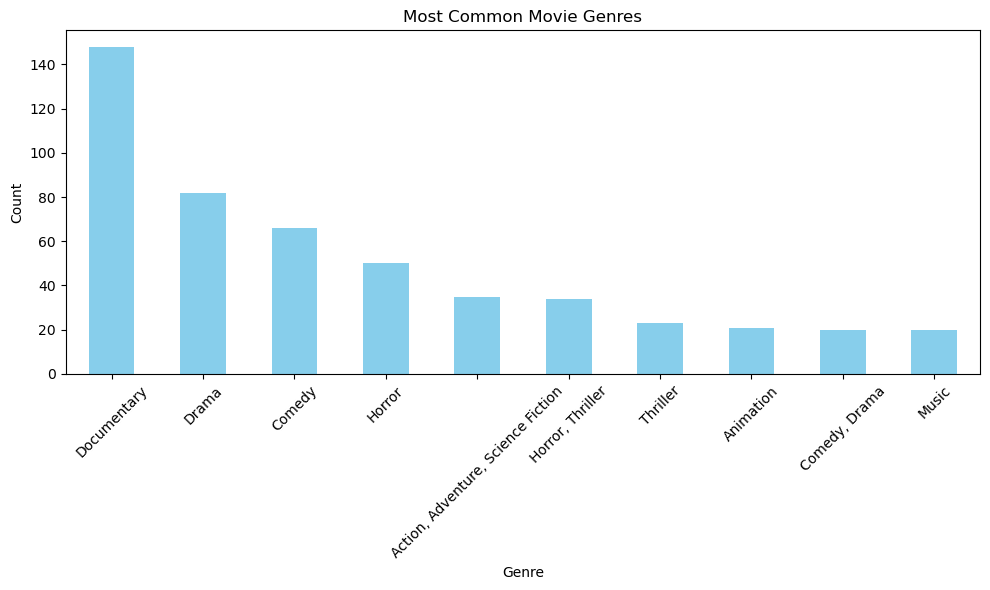

In [14]:
# (a) Most common movie genres
print("\nVisualizing most common movie genres...")
plt.figure(figsize=(10, 6))
df['Genres'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Most Common Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualizing trends in movie releases over time...


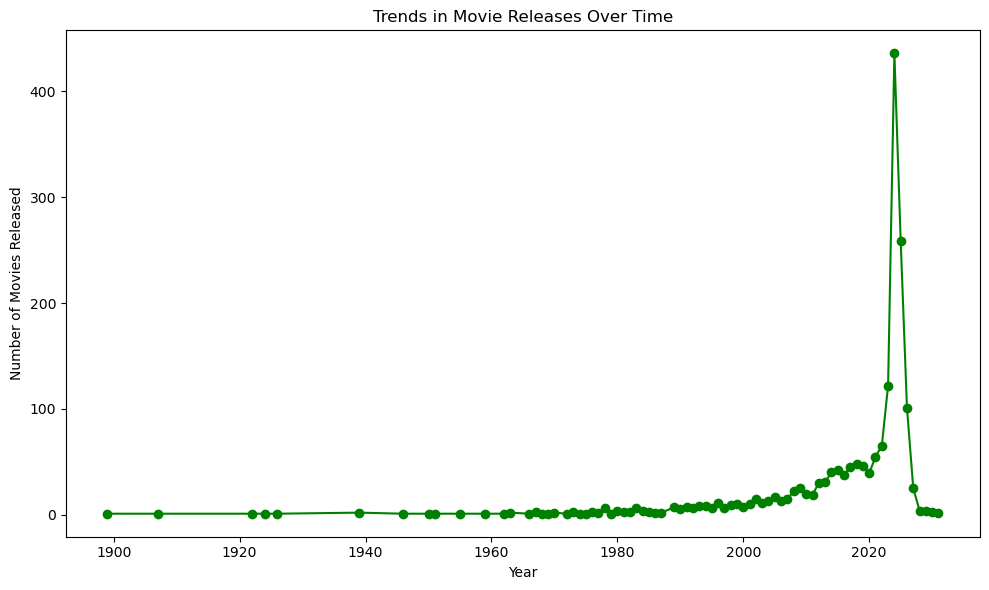

In [15]:
# (b) Trends in movie releases over time
print("Visualizing trends in movie releases over time...")
plt.figure(figsize=(10, 6))
df['Release Year'].value_counts().sort_index().plot(kind='line', marker='o', color='green')
plt.title("Trends in Movie Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Movies Released")
plt.tight_layout()
plt.show()

Visualizing distribution of ratings...


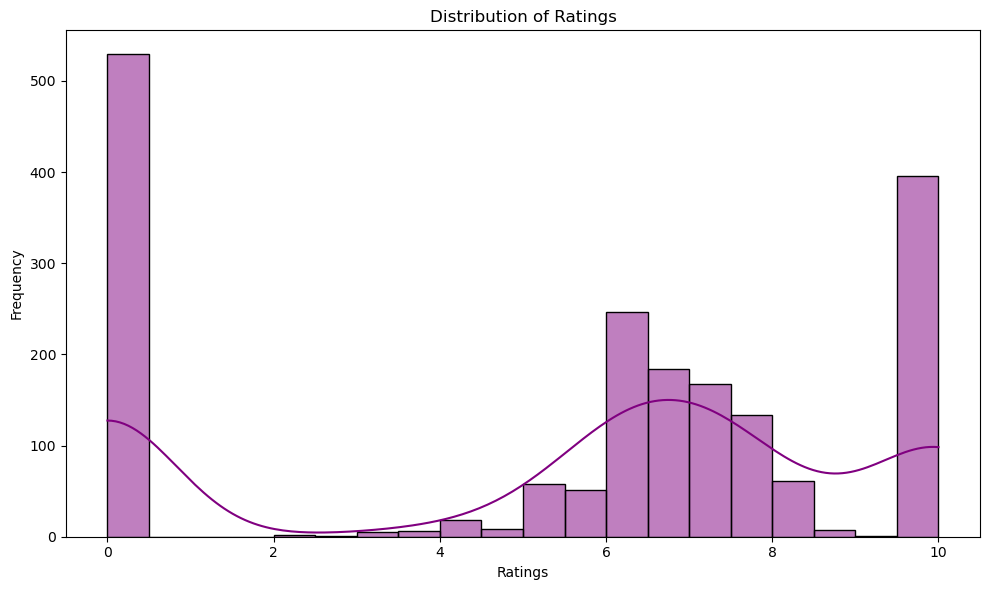

In [17]:
# (c) Distribution of ratings
print("Visualizing distribution of ratings...")
plt.figure(figsize=(10, 6))
sns.histplot(df['IMDb Rating'], kde=True, color='purple', bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

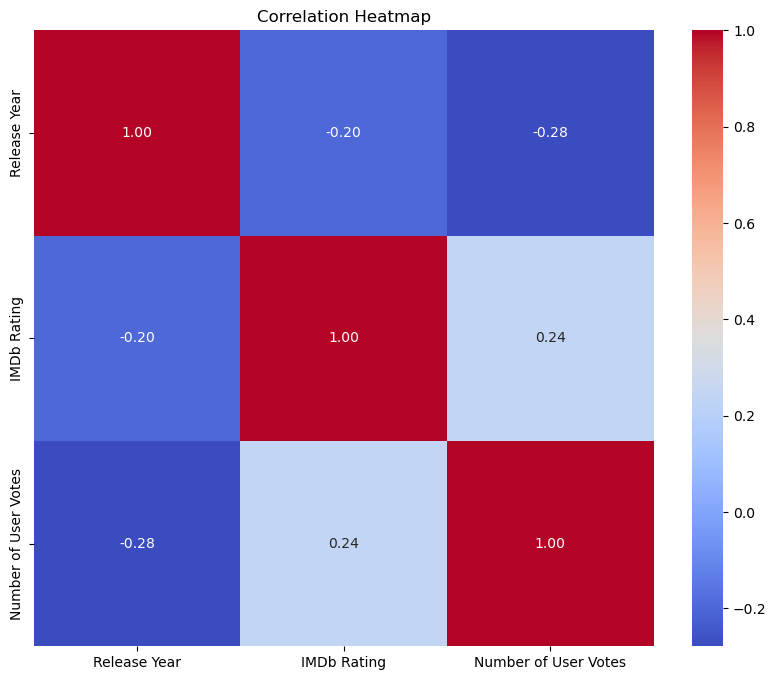

In [18]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numerical_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()
